In [32]:
import matplotlib.pyplot as plt
import joblib as jlb

from collections import Counter
from pyclustering.cluster.clarans import clarans
from pyclustering.utils import timedcall;
from Dataprepare.data_processing import D
from Dataprepare.data_processing import X_pca

In [22]:
features=[
 'balance',
 'purchases',
 'oneoff_purchases',
 'installments_purchases'
]
data=D[features].sample(1000)

In [23]:
print(data.shape)
print(data.tail(1))

(1000, 4)
       balance  purchases  oneoff_purchases  installments_purchases
3224  0.141125   0.987488           1.27722                1.087351


In [24]:
#data to list vi claran chi chap nhan list
datalist = data.values.tolist()
print(datalist[0])

[1.2176207711268332, -1.6864507608186394, -0.9960241096965925, -1.096107567646668]


In [ ]:
k = 3
n_local=5
max_nei=5
sample_sizes = [10, 50,200, 500,1000,2000,5000]
times = []
#show in plt
for size in sample_sizes:
    data_sample = data.sample(size)
    datasample_list = data_sample.values.tolist()
    (ticks,results) = timedcall(clarans(datasample_list, number_clusters=k, numlocal=n_local, maxneighbor=max_nei).process)  # xây dựng mô hình 
    times.append(ticks)
    print(f"Time for {size} samples: {ticks:.4f} seconds")
plt.figure(figsize=(10, 6))
plt.plot(sample_sizes, times, marker='o')
plt.title('CLARANS Clustering Time vs Sample Size')
plt.xlabel('Sample Size')
plt.ylabel('Time (seconds)')
plt.xscale('log')
plt.grid()
plt.show()

Time for 10 samples: 0.0174 seconds
Time for 50 samples: 1.3139 seconds
Time for 200 samples: 35.2920 seconds


In [25]:
#xay dung model clarans
k = 3
n_local=4
max_nei=4
Clarans_model = clarans(datalist, number_clusters=k, numlocal=n_local, maxneighbor=max_nei)
Clarans_model.process()

In [26]:
#lấy cluster và medoids
clusters = Clarans_model.get_clusters()
medoids = Clarans_model.get_medoids()

print("Clusters:", clusters)
print("Medoids:", medoids)

Clusters: [[1, 3, 7, 8, 9, 10, 11, 12, 13, 14, 15, 17, 19, 20, 21, 23, 24, 25, 27, 28, 30, 31, 32, 34, 36, 37, 38, 39, 40, 42, 43, 44, 46, 48, 49, 50, 52, 54, 55, 57, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 70, 71, 72, 73, 74, 81, 82, 83, 84, 85, 86, 87, 88, 90, 91, 94, 98, 99, 100, 101, 103, 104, 105, 106, 107, 108, 109, 110, 114, 115, 116, 117, 118, 119, 120, 123, 124, 125, 126, 127, 128, 130, 131, 132, 133, 137, 138, 140, 141, 142, 143, 145, 146, 148, 149, 151, 152, 154, 156, 157, 159, 160, 161, 162, 163, 164, 166, 167, 168, 169, 170, 171, 173, 176, 177, 179, 180, 181, 182, 183, 185, 186, 187, 190, 191, 193, 194, 195, 196, 198, 199, 200, 201, 202, 203, 204, 206, 207, 209, 210, 211, 214, 215, 216, 217, 218, 219, 220, 221, 222, 225, 226, 227, 228, 229, 230, 233, 234, 235, 237, 238, 239, 240, 242, 243, 244, 245, 246, 247, 248, 250, 252, 254, 255, 256, 257, 258, 260, 261, 262, 263, 264, 265, 267, 268, 269, 270, 271, 272, 274, 275, 276, 277, 278, 279, 280, 281, 282, 283, 284, 285, 287, 2

In [27]:
#gắn nhãn cluster đã có vào df
labels = [0] * len(data)

for cluster_id, cluster in enumerate(clusters):
    for index in cluster:
        labels[index] = cluster_id

data['cluster'] = labels
print(data.head(1))
print('\nKích thước clusters:', Counter(labels))
print('\n2 clusters lớn nhất:', Counter(labels).most_common(2))

       balance  purchases  oneoff_purchases  installments_purchases  cluster
4988  1.217621  -1.686451         -0.996024               -1.096108        2

Kích thước clusters: Counter({0: 750, 1: 168, 2: 82})

2 clusters lớn nhất: [(0, 750), (1, 168)]


In [28]:
#luu model
jlb.dump(Clarans_model,'../customer_clustering/Output/clarans.mdl')

['../customer_clustering/Output/clarans.mdl']

In [29]:
#load model
Loaded_Clarans_model = jlb.load('../customer_clustering/Output/clarans.mdl')

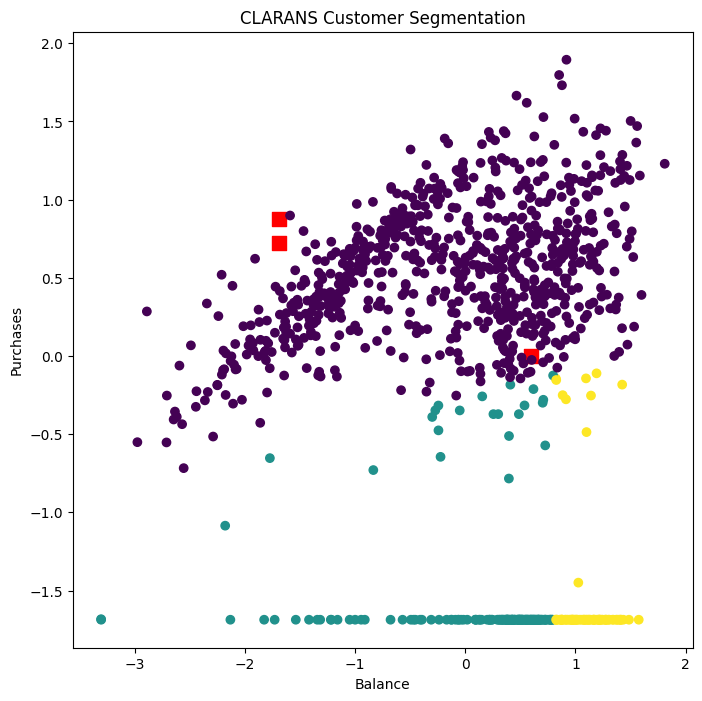

In [30]:
#hien thi model
medoid_points = data.iloc[medoids]

plt.figure(figsize=(8,8))

plt.scatter(medoid_points['purchases'],
            medoid_points['balance'],
            marker='s',
            s=100,color='red'
            )

plt.scatter(data['balance'],
            data['purchases'],
            c=data['cluster'])

plt.xlabel("Balance")
plt.ylabel("Purchases")
plt.title("CLARANS Customer Segmentation")

plt.show()

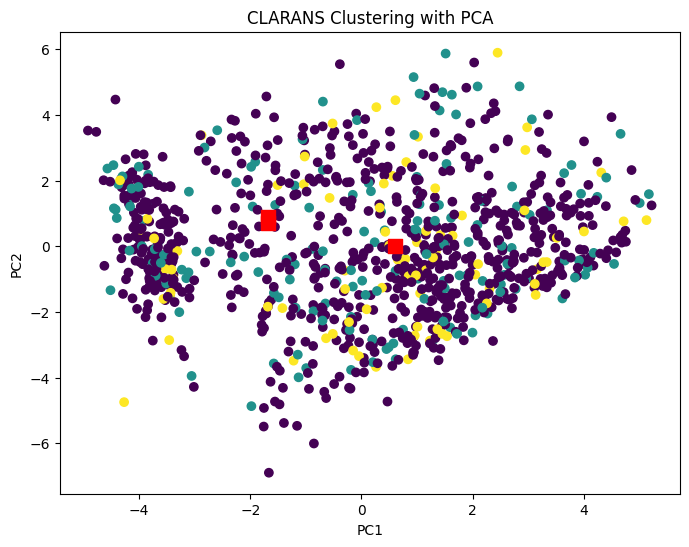

In [31]:
medoid_points = data.iloc[medoids]

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)
plt.scatter(medoid_points['purchases'],
            medoid_points['balance'],
            marker='s',
            s=100,color='red'
            )
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('CLARANS Clustering with PCA')
plt.show()